In [1]:
from astropy.table import Table
from astropy.time import Time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask.dataframe as dd
import sqlite3 

roots_tfm = '/home/julien/Documents/Etudes/Astrofisica/Master/TFM/Data'

In [2]:
filenames = ['Entries_UVOT_csv','Entries_OM_csv']
projects = ['Swift-UVOT', 'XMM-Newton']

In [3]:
filename = filenames[0]
project = projects[0]
filepath = roots_tfm + '/'+project+'/'+filename

In [4]:
dat = dd.read_csv(filepath)

In [5]:
dat.dtypes

SRCNUM                         int64
UVW2_FLUX                    float64
UVW2_FLUX_ERR                float64
UVM2_FLUX                    float64
UVM2_FLUX_ERR                float64
UVW1_FLUX                    float64
UVW1_FLUX_ERR                float64
U_FLUX                       float64
U_FLUX_ERR                   float64
B_FLUX                       float64
B_FLUX_ERR                   float64
V_FLUX                       float64
V_FLUX_ERR                   float64
UVW2_QUALITY_FLAG            float64
UVM2_QUALITY_FLAG            float64
UVW1_QUALITY_FLAG            float64
U_QUALITY_FLAG               float64
B_QUALITY_FLAG               float64
V_QUALITY_FLAG               float64
UVW2_EXTENDED        string[pyarrow]
UVM2_EXTENDED        string[pyarrow]
UVW1_EXTENDED        string[pyarrow]
U_EXTENDED           string[pyarrow]
B_EXTENDED           string[pyarrow]
V_EXTENDED           string[pyarrow]
MJD_START                    float64
OBSID_1                        int64
d

In [6]:
dat.head(20)

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD_START,OBSID_1
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,False,False,<NA>,<NA>,<NA>,<NA>,54973.746285,37683001
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,False,False,<NA>,<NA>,<NA>,<NA>,54973.746285,37683001
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0.0,0.0,<NA>,<NA>,<NA>,False,False,False,55460.217431,31814001
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,NaN,NaN,<NA>,<NA>,<NA>,False,<NA>,<NA>,55460.281007,31814002
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,NaN,NaN,<NA>,<NA>,<NA>,False,<NA>,<NA>,55468.007523,41138004
5,4,1.230489e-16,1.687670e-17,2.194885e-16,2.304008e-17,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,False,False,<NA>,<NA>,<NA>,<NA>,55413.664630,41138001
6,4,NaN,NaN,1.822581e-16,1.593429e-17,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,<NA>,False,<NA>,<NA>,<NA>,<NA>,55438.008171,41138002
7,4,NaN,NaN,NaN,NaN,5.510053e-16,3.349992e-17,NaN,NaN,NaN,...,NaN,NaN,<NA>,<NA>,False,<NA>,<NA>,<NA>,55467.000856,41138003
8,5,1.538364e-16,1.468865e-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,False,<NA>,<NA>,<NA>,<NA>,<NA>,55301.956921,90986001
9,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,False,55173.666250,378554001


In [7]:
from pandas.api.types import CategoricalDtype
cat_type = CategoricalDtype(categories=["True","False","<NA>"], ordered=False)

In [8]:
dat = dat.rename(columns={'OBSID_1': 'OBSID','MJD_START' : 'MJD'})
dat['UVW2_QUALITY_FLAG'] = dat['UVW2_QUALITY_FLAG'].fillna(value=999)
dat['UVW1_QUALITY_FLAG']= dat['UVW1_QUALITY_FLAG'].fillna(value=999)
dat['UVM2_QUALITY_FLAG']= dat['UVM2_QUALITY_FLAG'].fillna(value=999)
dat['U_QUALITY_FLAG']= dat['U_QUALITY_FLAG'].fillna(value=999)
dat['V_QUALITY_FLAG']= dat['V_QUALITY_FLAG'].fillna(value=999)
dat['B_QUALITY_FLAG']= dat['B_QUALITY_FLAG'].fillna(value=999)

In [9]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD,OBSID
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,999.0,999.0,False,False,<NA>,<NA>,<NA>,<NA>,54973.746285,37683001
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,999.0,999.0,False,False,<NA>,<NA>,<NA>,<NA>,54973.746285,37683001
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0.0,0.0,<NA>,<NA>,<NA>,False,False,False,55460.217431,31814001
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,999.0,999.0,<NA>,<NA>,<NA>,False,<NA>,<NA>,55460.281007,31814002
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,999.0,999.0,<NA>,<NA>,<NA>,False,<NA>,<NA>,55468.007523,41138004


In [10]:
dat = dat.astype({'SRCNUM': np.int32, 'UVW2_FLUX': np.float32, 'UVM2_FLUX': np.float32, 'UVW1_FLUX': np.float32, 'U_FLUX': np.float32,\
           'B_FLUX': np.float32, 'V_FLUX': np.float32, 'UVW2_FLUX_ERR': np.float32, 'UVM2_FLUX_ERR': np.float32, 'UVW1_FLUX_ERR': np.float32, \
            'U_FLUX_ERR': np.float32, 'B_FLUX_ERR': np.float32, 'V_FLUX_ERR': np.float32, 'UVW2_EXTENDED': cat_type, 'UVM2_EXTENDED': cat_type,\
            'UVW1_EXTENDED': cat_type, 'U_EXTENDED': cat_type, 'B_EXTENDED': cat_type, 'V_EXTENDED': cat_type, 'UVW2_QUALITY_FLAG': np.uint16,\
            'UVM2_QUALITY_FLAG': np.uint16, 'UVW1_QUALITY_FLAG': np.uint16, 'U_QUALITY_FLAG': np.uint16, 'B_QUALITY_FLAG': np.uint16, \
            'V_QUALITY_FLAG': np.uint16, 'MJD': np.int32, 'OBSID': np.int32})

In [11]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD,OBSID
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,False,False,NaN,NaN,NaN,NaN,54973,37683001
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,False,False,NaN,NaN,NaN,NaN,54973,37683001
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0,0,NaN,NaN,NaN,False,False,False,55460,31814001
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,999,999,NaN,NaN,NaN,False,NaN,NaN,55460,31814002
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,999,999,NaN,NaN,NaN,False,NaN,NaN,55468,41138004


In [12]:
dat.dtypes

SRCNUM                  int32
UVW2_FLUX             float32
UVW2_FLUX_ERR         float32
UVM2_FLUX             float32
UVM2_FLUX_ERR         float32
UVW1_FLUX             float32
UVW1_FLUX_ERR         float32
U_FLUX                float32
U_FLUX_ERR            float32
B_FLUX                float32
B_FLUX_ERR            float32
V_FLUX                float32
V_FLUX_ERR            float32
UVW2_QUALITY_FLAG      uint16
UVM2_QUALITY_FLAG      uint16
UVW1_QUALITY_FLAG      uint16
U_QUALITY_FLAG         uint16
B_QUALITY_FLAG         uint16
V_QUALITY_FLAG         uint16
UVW2_EXTENDED        category
UVM2_EXTENDED        category
UVW1_EXTENDED        category
U_EXTENDED           category
B_EXTENDED           category
V_EXTENDED           category
MJD                     int32
OBSID                   int32
dtype: object

In [13]:
dat.head(20)

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD,OBSID
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,False,False,NaN,NaN,NaN,NaN,54973,37683001
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,False,False,NaN,NaN,NaN,NaN,54973,37683001
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0,0,NaN,NaN,NaN,False,False,False,55460,31814001
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,999,999,NaN,NaN,NaN,False,NaN,NaN,55460,31814002
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,999,999,NaN,NaN,NaN,False,NaN,NaN,55468,41138004
5,4,1.230489e-16,1.687670e-17,2.194885e-16,2.304008e-17,NaN,NaN,NaN,NaN,NaN,...,999,999,False,False,NaN,NaN,NaN,NaN,55413,41138001
6,4,NaN,NaN,1.822581e-16,1.593429e-17,NaN,NaN,NaN,NaN,NaN,...,999,999,NaN,False,NaN,NaN,NaN,NaN,55438,41138002
7,4,NaN,NaN,NaN,NaN,5.510053e-16,3.349992e-17,NaN,NaN,NaN,...,999,999,NaN,NaN,False,NaN,NaN,NaN,55467,41138003
8,5,1.538364e-16,1.468865e-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999,999,False,NaN,NaN,NaN,NaN,NaN,55301,90986001
9,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999,0,NaN,NaN,NaN,NaN,NaN,False,55173,378554001


In [14]:
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].fillna(value="<NA>")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].fillna(value="<NA>")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].fillna(value="<NA>")
dat['U_EXTENDED']= dat['U_EXTENDED'].fillna(value="<NA>")
dat['V_EXTENDED']= dat['V_EXTENDED'].fillna(value="<NA>")
dat['B_EXTENDED']= dat['B_EXTENDED'].fillna(value="<NA>")

In [15]:
df_match = Table.read( roots_tfm + '/Swift-UVOT/Match_OM/match_uvot_om').to_pandas()
df_match.head()

,SRCNUM_OM,RA_OM,DEC_OM,POSERR_OM,COUNT_OM,SRCNUM_UVOT,RA_UVOT,DEC_UVOT,POSERR_UVOT,COUNT_UVOT,Separation,angDist
0,5,0.000172,8.371812,0.579813,1,1,0.000160,8.371681,0.273446,1,0.185867,0.475779
1,66,0.004279,8.249917,0.736678,1,10,0.004393,8.250327,0.318405,1,0.484476,1.533487
2,102,0.005933,8.163762,0.709919,1,11,0.005988,8.163922,0.317418,1,0.197048,0.607305
3,182,0.010155,8.307648,0.663965,1,20,0.010337,8.307771,0.316142,1,0.267008,0.785089
4,494,0.026486,8.306166,0.719527,1,64,0.026368,8.306161,0.307228,1,0.136319,0.419898


In [16]:
df_match = df_match.drop(columns=['RA_OM','DEC_OM','POSERR_OM','COUNT_OM','RA_UVOT','DEC_UVOT','POSERR_UVOT','COUNT_UVOT','Separation','angDist'])

In [17]:
#dat_UVOT_match = dat[dat['SRCNUM'].isin(df_match['SRCNUM_UVOT'])].compute()
#dat_UVOT_match.shape

In [18]:
df_source = pd.read_csv(roots_tfm + '/SOURCE_complete_galaxies.csv')
dat_UVOT = dat[dat['SRCNUM'].isin(df_source['SRCNUM_UVOT'])].compute()
dat_UVOT.shape

(724191, 27)

In [19]:
#dat_UVOT.to_csv(roots_tfm + '/Swift-UVOT/Entries_UVOT_galaxies.csv',index=True)

In [20]:
filename = filenames[1]
project = projects[1]
filepath = roots_tfm + '/'+project+'/'+filename

In [21]:
dat = dd.read_csv(filepath)

In [22]:
dat.dtypes

SRCNUM                  int64
UVW2_AB_FLUX          float64
UVW2_AB_FLUX_ERR      float64
UVM2_AB_FLUX          float64
UVM2_AB_FLUX_ERR      float64
UVW1_AB_FLUX          float64
UVW1_AB_FLUX_ERR      float64
U_AB_FLUX             float64
U_AB_FLUX_ERR         float64
B_AB_FLUX             float64
B_AB_FLUX_ERR         float64
V_AB_FLUX             float64
V_AB_FLUX_ERR         float64
UVW2_QUALITY_FLAG     float64
UVM2_QUALITY_FLAG     float64
UVW1_QUALITY_FLAG     float64
U_QUALITY_FLAG        float64
B_QUALITY_FLAG        float64
V_QUALITY_FLAG        float64
UVW2_EXTENDED_FLAG    float64
UVM2_EXTENDED_FLAG    float64
UVW1_EXTENDED_FLAG    float64
U_EXTENDED_FLAG       float64
B_EXTENDED_FLAG       float64
V_EXTENDED_FLAG       float64
MJD_START             float64
OBSID_1                 int64
dtype: object

In [23]:
dat = dat.rename(columns={'UVW2_AB_FLUX':'UVW2_FLUX','UVW1_AB_FLUX': 'UVW1_FLUX','UVM2_AB_FLUX':'UVM2_FLUX', 'U_AB_FLUX':'U_FLUX',\
                    'V_AB_FLUX':'V_FLUX', 'B_AB_FLUX':'B_FLUX', 'UVW2_AB_FLUX_ERR':'UVW2_FLUX_ERR','UVW1_AB_FLUX_ERR': 'UVW1_FLUX_ERR', \
                    'UVM2_AB_FLUX_ERR':'UVM2_FLUX_ERR', 'U_AB_FLUX_ERR':'U_FLUX_ERR','V_AB_FLUX_ERR':'V_FLUX_ERR', \
                    'B_AB_FLUX_ERR':'B_FLUX_ERR', 'MJD_START' : 'MJD','UVW2_EXTENDED_FLAG' : 'UVW2_EXTENDED', \
                    'UVM2_EXTENDED_FLAG' : 'UVM2_EXTENDED','UVW1_EXTENDED_FLAG' : 'UVW1_EXTENDED','U_EXTENDED_FLAG' : 'U_EXTENDED', \
                    'B_EXTENDED_FLAG' : 'B_EXTENDED', 'V_EXTENDED_FLAG' : 'V_EXTENDED', 'OBSID_1': 'OBSID'})

In [24]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD,OBSID
0,1,NaN,NaN,NaN,NaN,NaN,NaN,2.719044e-17,2.718755e-18,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,58972.664606,862640901
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.996124e-17,...,130.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,54134.548438,403390101
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.180818e-18,...,2.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,56291.869572,700990101
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.246593e-18,...,2.0,2.0,NaN,NaN,NaN,NaN,0.0,0.0,56291.869572,700990101
4,4,NaN,NaN,NaN,NaN,1.674826e-17,3.007949e-18,8.403160e-18,1.727042e-18,NaN,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,56086.733368,693190101


In [25]:
dat['UVW2_QUALITY_FLAG'] = dat['UVW2_QUALITY_FLAG'].fillna(value=999)
dat['UVW1_QUALITY_FLAG']= dat['UVW1_QUALITY_FLAG'].fillna(value=999)
dat['UVM2_QUALITY_FLAG']= dat['UVM2_QUALITY_FLAG'].fillna(value=999)
dat['U_QUALITY_FLAG']= dat['U_QUALITY_FLAG'].fillna(value=999)
dat['V_QUALITY_FLAG']= dat['V_QUALITY_FLAG'].fillna(value=999)
dat['B_QUALITY_FLAG']= dat['B_QUALITY_FLAG'].fillna(value=999)
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].fillna(value="<NA>")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].fillna(value="<NA>")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].fillna(value="<NA>")
dat['U_EXTENDED']= dat['U_EXTENDED'].fillna(value="<NA>")
dat['V_EXTENDED']= dat['V_EXTENDED'].fillna(value="<NA>")
dat['B_EXTENDED']= dat['B_EXTENDED'].fillna(value="<NA>")
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].mask(dat['UVW2_EXTENDED']==0,"False")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].mask(dat['UVW1_EXTENDED']==0,"False")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].mask(dat['UVM2_EXTENDED']==0,"False")
dat['U_EXTENDED']= dat['U_EXTENDED'].mask(dat['U_EXTENDED']==0,"False")
dat['V_EXTENDED']= dat['V_EXTENDED'].mask(dat['V_EXTENDED']==0,"False")
dat['B_EXTENDED']= dat['B_EXTENDED'].mask(dat['B_EXTENDED']==0,"False")
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].mask(dat['UVW2_EXTENDED']==1,"True")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].mask(dat['UVW1_EXTENDED']==1,"True")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].mask(dat['UVM2_EXTENDED']==1,"True")
dat['U_EXTENDED']= dat['U_EXTENDED'].mask(dat['U_EXTENDED']==1,"True")
dat['V_EXTENDED']= dat['V_EXTENDED'].mask(dat['V_EXTENDED']==1,"True")
dat['B_EXTENDED']= dat['B_EXTENDED'].mask(dat['B_EXTENDED']==1,"True")

In [26]:
dat.head(20)

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD,OBSID
0,1,NaN,NaN,NaN,NaN,NaN,NaN,2.719044e-17,2.718755e-18,NaN,...,999.0,999.0,<NA>,<NA>,<NA>,False,<NA>,<NA>,58972.664606,862640901
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.996124e-17,...,130.0,999.0,<NA>,<NA>,<NA>,<NA>,False,<NA>,54134.548438,403390101
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.180818e-18,...,2.0,999.0,<NA>,<NA>,<NA>,<NA>,False,<NA>,56291.869572,700990101
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.246593e-18,...,2.0,2.0,<NA>,<NA>,<NA>,<NA>,False,False,56291.869572,700990101
4,4,NaN,NaN,NaN,NaN,1.674826e-17,3.007949e-18,8.403160e-18,1.727042e-18,NaN,...,999.0,999.0,<NA>,<NA>,False,False,<NA>,<NA>,56086.733368,693190101
5,5,NaN,NaN,1.808012e-16,1.486755e-17,NaN,NaN,NaN,NaN,NaN,...,999.0,999.0,<NA>,False,<NA>,<NA>,<NA>,<NA>,57016.955150,741581501
6,6,5.085729e-16,5.509988e-17,5.487070e-16,4.128383e-17,1.396086e-15,2.901988e-17,NaN,NaN,4.391370e-15,...,0.0,999.0,False,False,False,<NA>,False,<NA>,54134.548438,403390101
7,7,NaN,NaN,NaN,NaN,2.147780e-17,4.352068e-18,NaN,NaN,NaN,...,999.0,999.0,<NA>,<NA>,False,<NA>,<NA>,<NA>,59205.227269,864053501
8,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.997491e-17,...,70.0,999.0,<NA>,<NA>,<NA>,<NA>,False,<NA>,54134.548438,403390101
9,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999.0,6.0,<NA>,<NA>,<NA>,<NA>,<NA>,False,56291.869572,700990101


In [27]:
dat = dat.astype({'SRCNUM': np.int32, 'UVW2_FLUX': np.float32, 'UVM2_FLUX': np.float32, 'UVW1_FLUX': np.float32, 'U_FLUX': np.float32,\
           'B_FLUX': np.float32, 'V_FLUX': np.float32, 'UVW2_FLUX_ERR': np.float32, 'UVM2_FLUX_ERR': np.float32, 'UVW1_FLUX_ERR': np.float32, \
            'U_FLUX_ERR': np.float32, 'B_FLUX_ERR': np.float32, 'V_FLUX_ERR': np.float32, 'MJD': np.int32, 'UVW2_QUALITY_FLAG': np.uint16,\
            'UVM2_QUALITY_FLAG': np.uint16, 'UVW1_QUALITY_FLAG': np.uint16, 'U_QUALITY_FLAG': np.uint16, 'B_QUALITY_FLAG': np.uint16, \
            'V_QUALITY_FLAG': np.uint16, 'UVW2_EXTENDED': cat_type, 'UVM2_EXTENDED': cat_type,\
            'UVW1_EXTENDED': cat_type, 'U_EXTENDED': cat_type, 'B_EXTENDED': cat_type, 'V_EXTENDED': cat_type, 'OBSID': np.int32})

In [28]:
dat.head(20)

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD,OBSID
0,1,NaN,NaN,NaN,NaN,NaN,NaN,2.719044e-17,2.718755e-18,NaN,...,999,999,<NA>,<NA>,<NA>,False,<NA>,<NA>,58972,862640901
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.996124e-17,...,130,999,<NA>,<NA>,<NA>,<NA>,False,<NA>,54134,403390101
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.180818e-18,...,2,999,<NA>,<NA>,<NA>,<NA>,False,<NA>,56291,700990101
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.246593e-18,...,2,2,<NA>,<NA>,<NA>,<NA>,False,False,56291,700990101
4,4,NaN,NaN,NaN,NaN,1.674827e-17,3.007949e-18,8.403160e-18,1.727042e-18,NaN,...,999,999,<NA>,<NA>,False,False,<NA>,<NA>,56086,693190101
5,5,NaN,NaN,1.808012e-16,1.486755e-17,NaN,NaN,NaN,NaN,NaN,...,999,999,<NA>,False,<NA>,<NA>,<NA>,<NA>,57016,741581501
6,6,5.085729e-16,5.509988e-17,5.487070e-16,4.128383e-17,1.396086e-15,2.901988e-17,NaN,NaN,4.391370e-15,...,0,999,False,False,False,<NA>,False,<NA>,54134,403390101
7,7,NaN,NaN,NaN,NaN,2.147780e-17,4.352068e-18,NaN,NaN,NaN,...,999,999,<NA>,<NA>,False,<NA>,<NA>,<NA>,59205,864053501
8,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.997491e-17,...,70,999,<NA>,<NA>,<NA>,<NA>,False,<NA>,54134,403390101
9,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999,6,<NA>,<NA>,<NA>,<NA>,<NA>,False,56291,700990101


In [29]:
#dat.to_parquet(roots_tfm + '/'+project+'/'+'Entries_OM_parquet')

In [30]:
#at_OM_match = dat[dat['SRCNUM'].isin(df_match['SRCNUM_OM'])].compute()
#dat_OM_match.shape

In [31]:
dat_OM = dat[dat['SRCNUM'].isin(df_source['SRCNUM_OM'])].compute()
dat_OM.shape

(439612, 27)

In [32]:
dat_UVOT['U_EXTENDED'].unique()

['<NA>', 'True', 'False']
Categories (3, object): ['True', 'False', '<NA>']

In [33]:
dat_OM['U_EXTENDED'].unique()

['True', '<NA>', 'False']
Categories (3, object): ['True', 'False', '<NA>']

In [34]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import CubicSpline
from scipy.stats import gaussian_kde
from scipy.optimize import fsolve

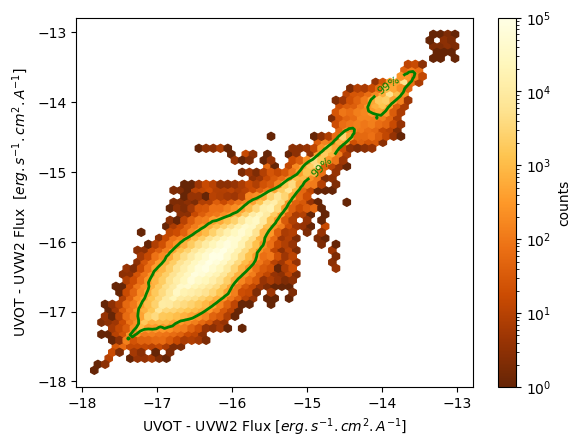

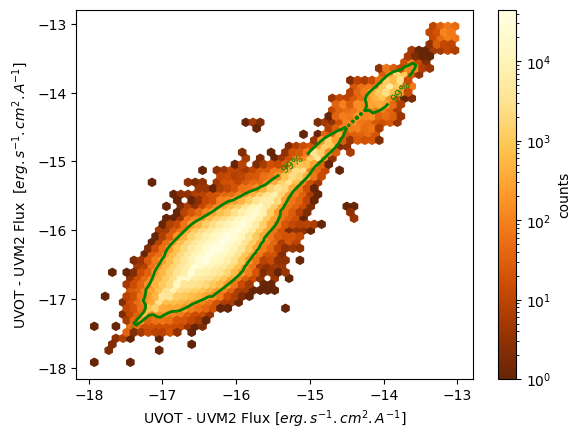

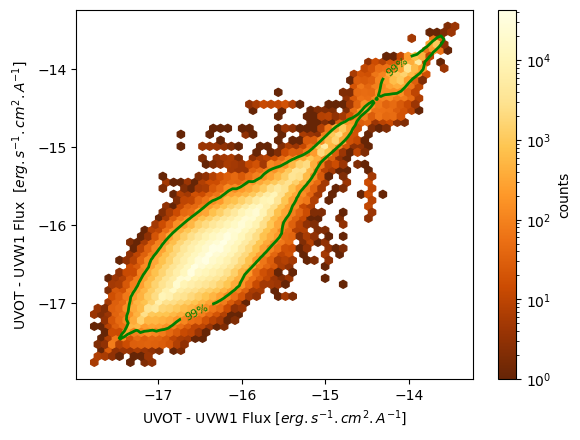

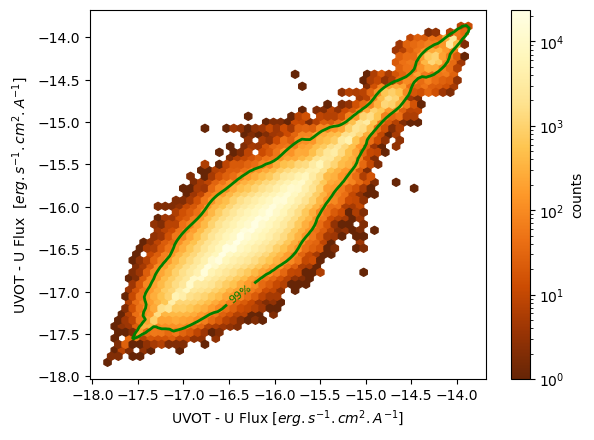

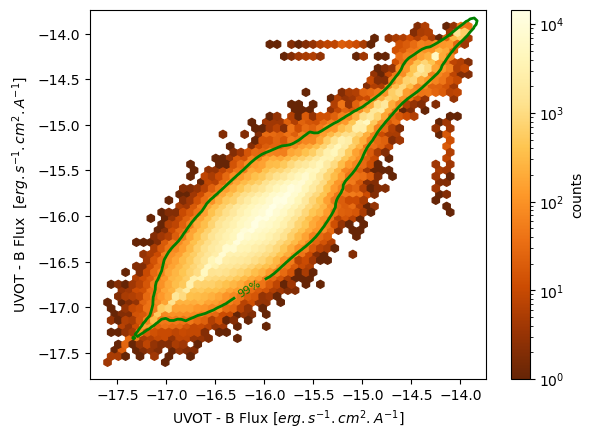

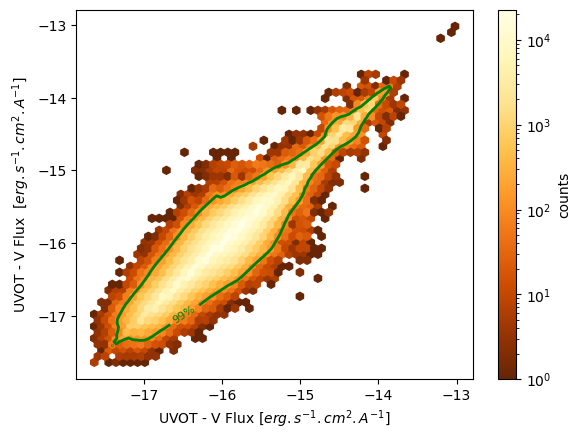

In [35]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index() 
    df_flux_uvot = df_flux_uvot[df_flux_uvot[flux_quality] == 0]

    df_flux_uvot = df_flux_uvot.merge(df_flux_uvot, on='SRCNUM')    
            
    # Plot figure
    fig, ax =plt.subplots()
    hb =ax.hexbin(np.log10(df_flux_uvot[flux_name+'_x']),np.log10(df_flux_uvot[flux_name+'_y']),gridsize=50, bins='log', cmap='YlOrBr_r')
    cb = fig.colorbar(hb, ax=ax, label='counts')
    
    xmin, xmax= ax.get_xlim()
    ymin, ymax= ax.get_ylim()

    random_row_index = np.random.default_rng().choice(df_flux_uvot.index.values,100000)
    data = np.vstack([np.log10(df_flux_uvot.loc[random_row_index,flux_name+'_x']),np.log10(df_flux_uvot.loc[random_row_index,flux_name+'_y'])])
    kde = gaussian_kde(data)
    grid_x, grid_y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
    z = kde(grid_coords).reshape(100, 100)
    thresholds=np.percentile(kde.evaluate(kde.resample(40000)),1)
    contour = plt.contour(grid_x,grid_y,z,levels=[thresholds],colors='green',linewidths=2)
    plt.clabel(contour, inline=True, fontsize=8, fmt={thresholds: f"{99}%"})

    ax.set_xlabel("UVOT - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.set_ylabel("UVOT - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    fig.savefig(roots_tfm + '/Calibration/UVOT_vs_UVOT_ ' + flux + '_galaxies.png',dpi=1200)  

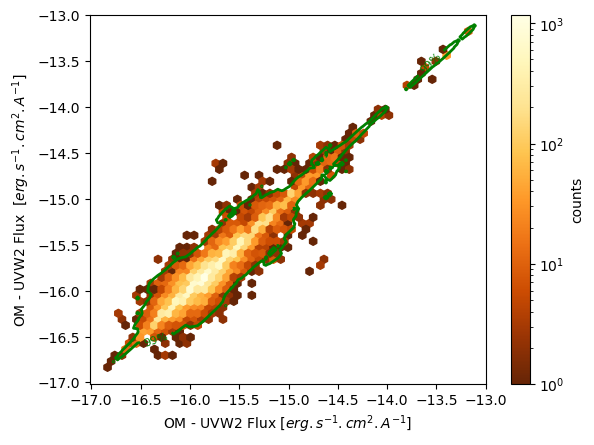

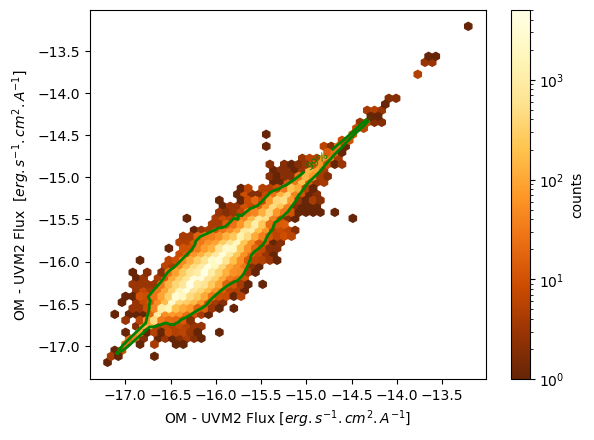

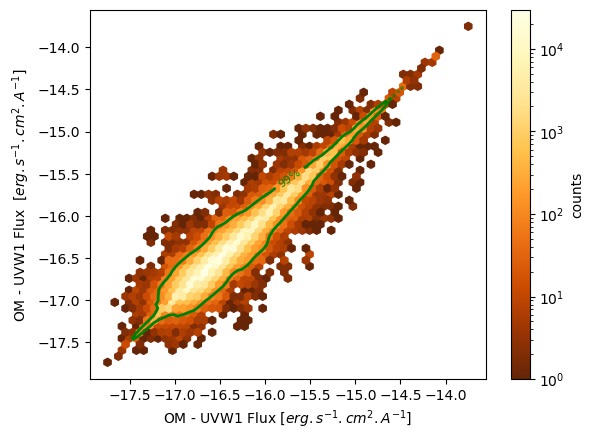

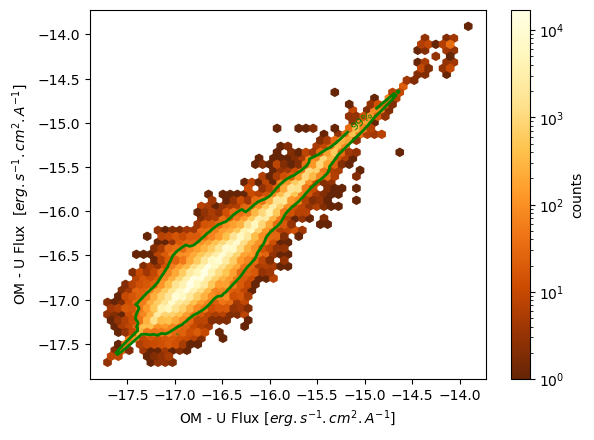

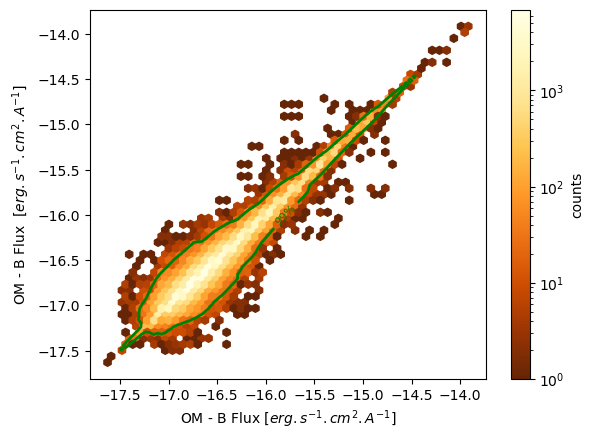

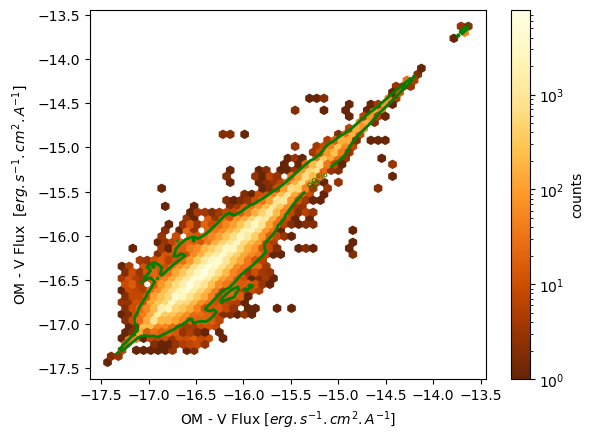

In [36]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]
    df_flux_om = df_flux_om.merge(df_flux_om, on='SRCNUM')

    # Plot figure
    fig, ax =plt.subplots()
    hb =ax.hexbin(np.log10(df_flux_om[flux_name+'_x']),np.log10(df_flux_om[flux_name+'_y']),gridsize=50, bins='log', cmap='YlOrBr_r')
    cb = fig.colorbar(hb, ax=ax, label='counts')

    xmin, xmax= ax.get_xlim()
    ymin, ymax= ax.get_ylim()
    
    random_row_index = np.random.default_rng().choice(df_flux_om.index.values,100000)
    data = np.vstack([np.log10(df_flux_om.loc[random_row_index,flux_name+'_x']),np.log10(df_flux_om.loc[random_row_index,flux_name+'_y'])])
    kde = gaussian_kde(data)
    grid_x, grid_y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
    z = kde(grid_coords).reshape(100, 100)
    thresholds=np.percentile(kde.evaluate(kde.resample(40000)),1)
    contour = plt.contour(grid_x,grid_y,z,levels=[thresholds],colors='green',linewidths=2)
    plt.clabel(contour, inline=True, fontsize=8, fmt={thresholds: f"{99}%"})

    ax.set_xlabel("OM - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.set_ylabel("OM - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    fig.savefig(roots_tfm + '/Calibration/OM_vs_OM_ ' + flux + '_galaxies.png',dpi=1200) 

In [37]:
dat_UVOT_cor = dat_UVOT.copy()
dat_UVOT_cor = dat_UVOT_cor.astype({'UVW2_FLUX': np.float64, 'UVM2_FLUX': np.float64, 'UVW1_FLUX': np.float64, 'U_FLUX': np.float64,\
           'B_FLUX': np.float64, 'V_FLUX': np.float64})

/tmp/ipykernel_2835/3957170736.py:31: RankWarning: Polyfit may be poorly conditioned
  p1 = np.poly1d(np.polyfit(y,x, deg=3))
/tmp/ipykernel_2835/3957170736.py:55: RankWarning: Polyfit may be poorly conditioned
  p2 = np.poly1d(np.polyfit(y,x, deg=3))
/tmp/ipykernel_2835/3957170736.py:31: RankWarning: Polyfit may be poorly conditioned
  p1 = np.poly1d(np.polyfit(y,x, deg=3))
/tmp/ipykernel_2835/3957170736.py:55: RankWarning: Polyfit may be poorly conditioned
  p2 = np.poly1d(np.polyfit(y,x, deg=3))
/tmp/ipykernel_2835/3957170736.py:31: RankWarning: Polyfit may be poorly conditioned
  p1 = np.poly1d(np.polyfit(y,x, deg=3))
/tmp/ipykernel_2835/3957170736.py:55: RankWarning: Polyfit may be poorly conditioned
  p2 = np.poly1d(np.polyfit(y,x, deg=3))
/tmp/ipykernel_2835/3957170736.py:31: RankWarning: Polyfit may be poorly conditioned
  p1 = np.poly1d(np.polyfit(y,x, deg=3))
/tmp/ipykernel_2835/3957170736.py:55: RankWarning: Polyfit may be poorly conditioned
  p2 = np.poly1d(np.polyfit(y,x, 

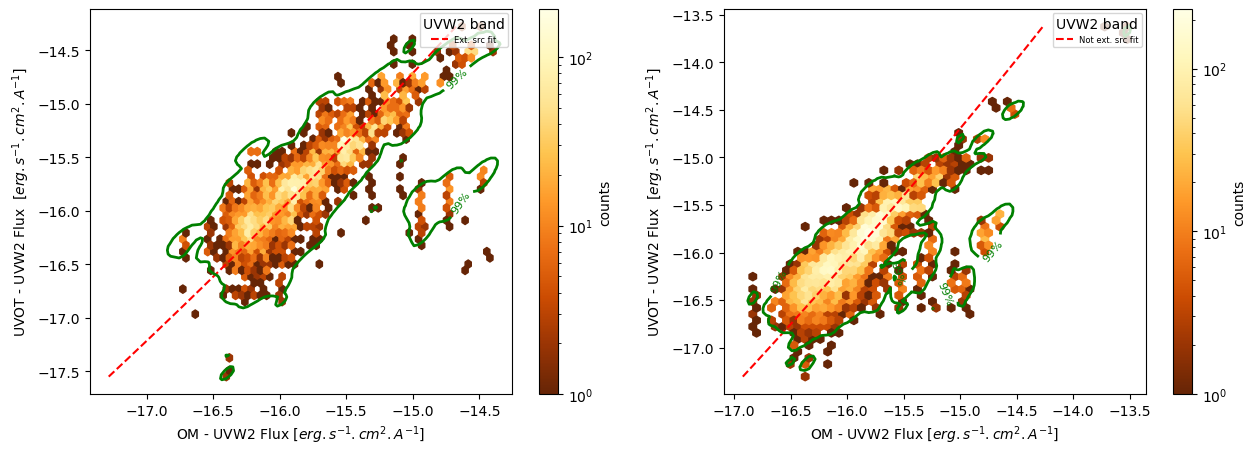

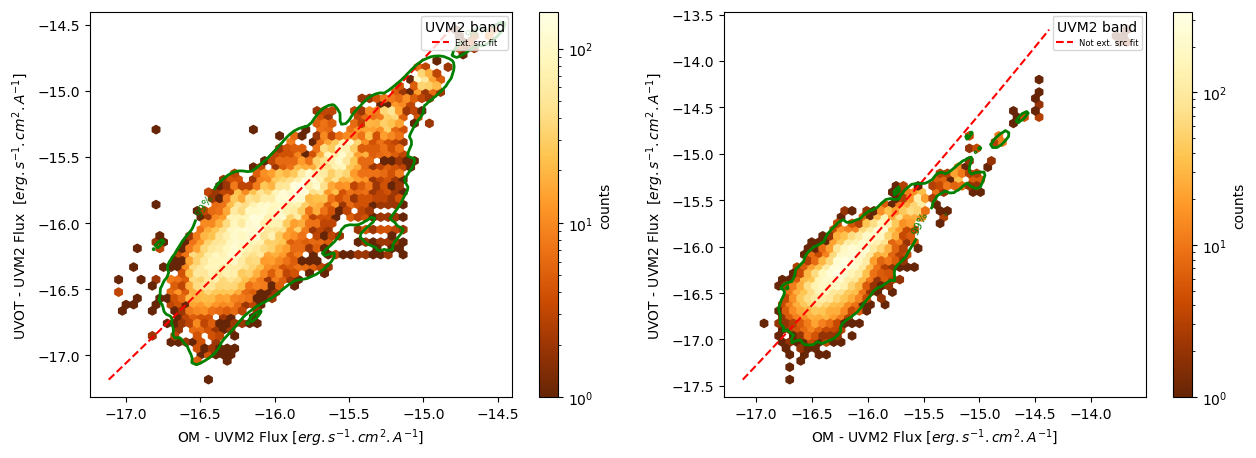

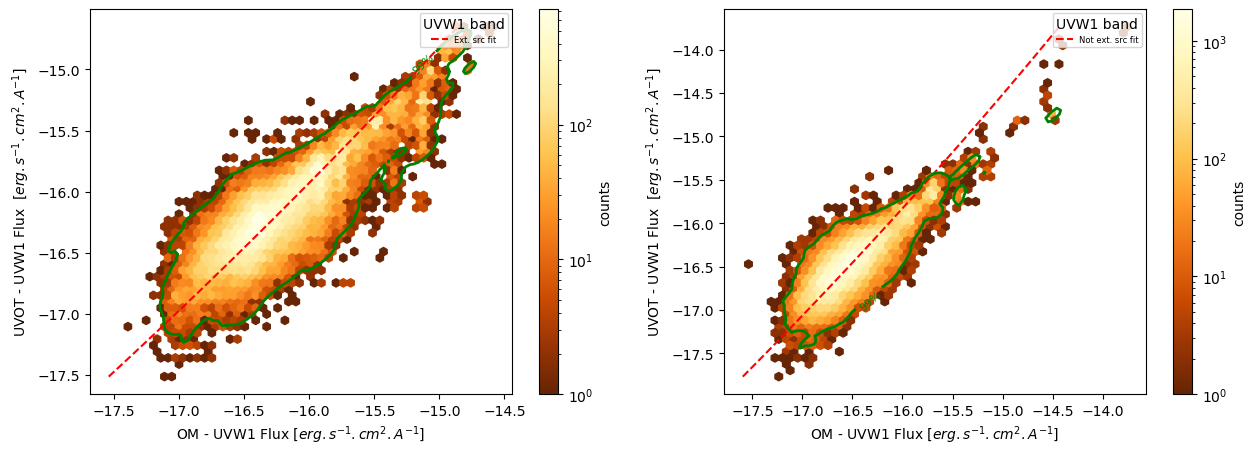

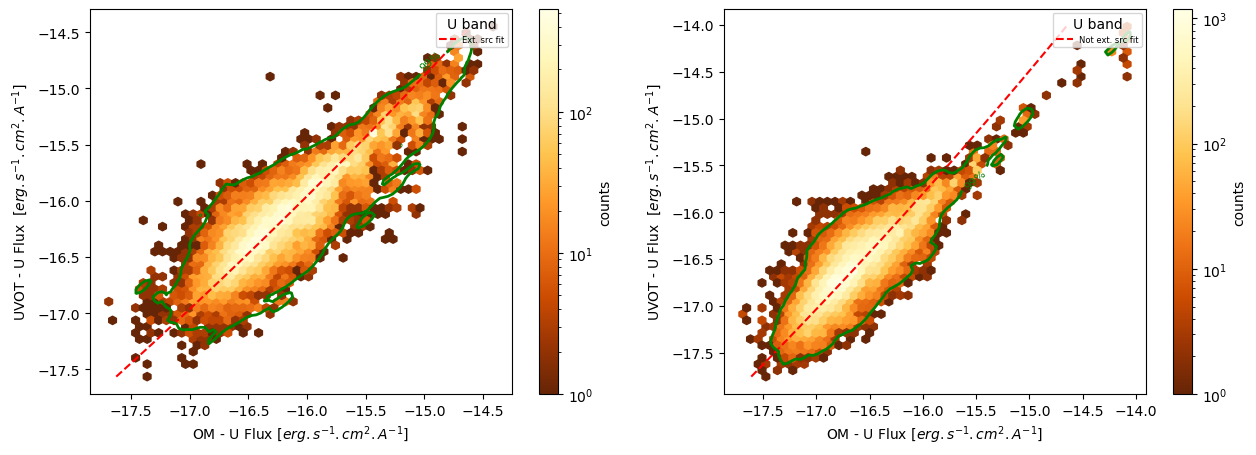

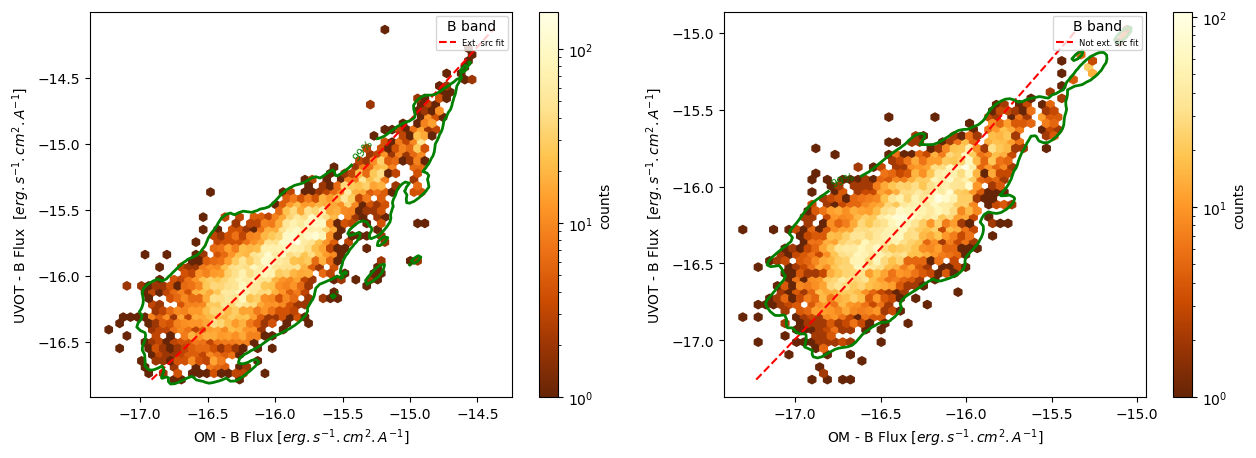

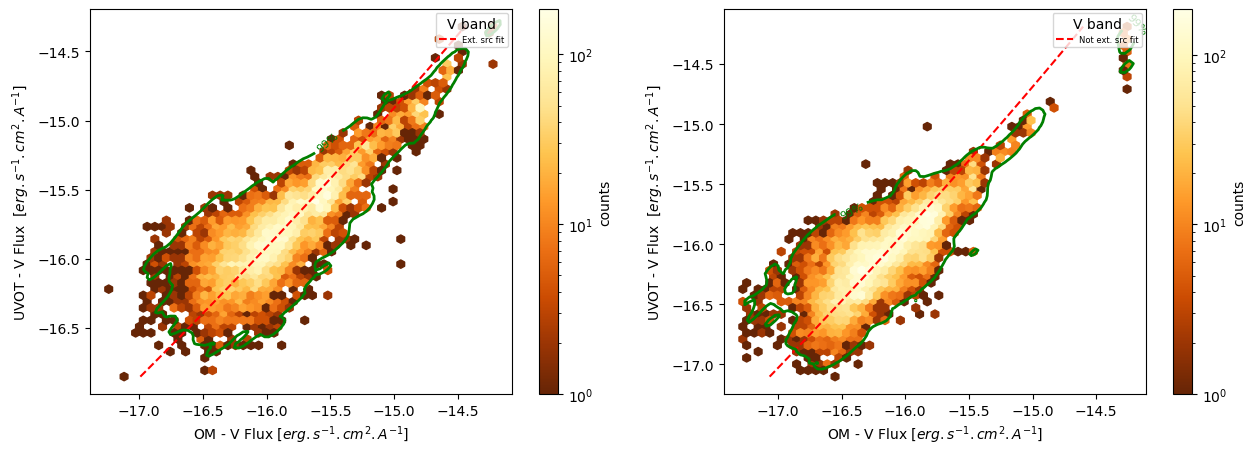

In [38]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index() 
    df_flux_uvot = df_flux_uvot[df_flux_uvot[flux_quality] == 0]

    # Data frame OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]

    # Merge results
    df_match = df_match.rename(columns={'SRCNUM_UVOT':'SRCNUM_UVOT_1','SRCNUM_OM':'SRCNUM_OM_1'})
    df_merge = df_match.merge(df_flux_uvot, left_on='SRCNUM_UVOT_1', right_on='SRCNUM', 
                              suffixes=(None,'_UVOT')).merge(df_flux_om, left_on='SRCNUM_OM_1', 
                                                             right_on='SRCNUM',suffixes=('_UVOT','_OM'))
    # Definition conservative of extended source
    ind_extended = (df_merge[flag_extended+ '_UVOT'] == "True") | (df_merge[flag_extended+ '_OM'] == "True")
    
    # Plot figures
    fig, (ax1, ax2) =plt.subplots(1,2,figsize=(15, 5))
     
    x=np.log10(df_merge.loc[ind_extended,flux_name + '_OM'])
    y=np.log10(df_merge.loc[ind_extended,flux_name + '_UVOT'])
    hb =ax1.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr_r')
    cb = fig.colorbar(hb, ax=ax1, label='counts')
    p1 = np.poly1d(np.polyfit(y,x, deg=3))
    yp = np.linspace(y.min(), y.max(), 100)
    ax1.plot(p1(yp), yp, color='r', linestyle='dashed', label= "Ext. src fit")  
    ax1.set_xlabel("OM - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax1.set_ylabel("UVOT - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax1.legend(loc='upper right',prop={'size': 6},title= flux + " band")

    xmin, xmax= ax1.get_xlim()
    ymin, ymax= ax1.get_ylim()

    random_row_index = np.random.default_rng().choice(df_merge.loc[ind_extended,:].index.values,100000)
    data = np.vstack([np.log10(df_merge.loc[random_row_index,flux_name+'_OM']),np.log10(df_merge.loc[random_row_index,flux_name+'_UVOT'])])
    kde = gaussian_kde(data)
    grid_x, grid_y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
    z = kde(grid_coords).reshape(100, 100)
    thresholds=np.percentile(kde.evaluate(kde.resample(40000)),1)
    contour = ax1.contour(grid_x,grid_y,z,levels=[thresholds],colors='green',linewidths=2)
    ax1.clabel(contour, inline=True, fontsize=8, fmt={thresholds: f"{99}%"})

    x=np.log10(df_merge.loc[~ind_extended,flux_name + '_OM'])
    y=np.log10(df_merge.loc[~ind_extended,flux_name + '_UVOT']) 
    hb =ax2.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr_r')
    cb = fig.colorbar(hb, ax=ax2, label='counts')
    p2 = np.poly1d(np.polyfit(y,x, deg=3))
    yp = np.linspace(y.min(), y.max(), 100)
    ax2.plot(p2(yp), yp, color='r', linestyle='dashed', label= "Not ext. src fit")
    ax2.set_xlabel("OM - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax2.set_ylabel("UVOT - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax2.legend(loc='upper right',prop={'size': 6},title= flux + " band")

    xmin, xmax= ax2.get_xlim()
    ymin, ymax= ax2.get_ylim()

    random_row_index = np.random.default_rng().choice(df_merge.loc[~ind_extended,:].index.values,100000)
    data = np.vstack([np.log10(df_merge.loc[random_row_index,flux_name+'_OM']),np.log10(df_merge.loc[random_row_index,flux_name+'_UVOT'])])
    kde = gaussian_kde(data)
    grid_x, grid_y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
    z = kde(grid_coords).reshape(100, 100)
    thresholds=np.percentile(kde.evaluate(kde.resample(40000)),1)
    contour = ax2.contour(grid_x,grid_y,z,levels=[thresholds],colors='green',linewidths=2)
    ax2.clabel(contour, inline=True, fontsize=8, fmt={thresholds: f"{99}%"})
    
    fig.savefig(roots_tfm + '/Calibration/OM_vs_UVOT_ ' + flux + '_galaxies.png',dpi=1200)  

    ind_extended_uvot = (dat_UVOT[flag_extended]=="True")
    #dat_OM_cor.loc[ind_extended_om, flux_name] = [10**fsolve(p-x,x)[0] for x in np.log10(dat_OM.loc[ind_extended_om, flux_name])]
    dat_UVOT_cor.loc[ind_extended_uvot, flux_name] = 10**p1(np.log10(dat_UVOT.loc[ind_extended_uvot, flux_name]))
    dat_UVOT_cor.loc[~ind_extended_uvot, flux_name] = 10**p2(np.log10(dat_UVOT.loc[~ind_extended_uvot, flux_name]))

In [39]:
p2

poly1d([ 2.27723270e-04, -1.15993437e-02,  3.15143251e-01, -7.14585452e+00])

In [40]:
df_match.shape

(595146, 2)

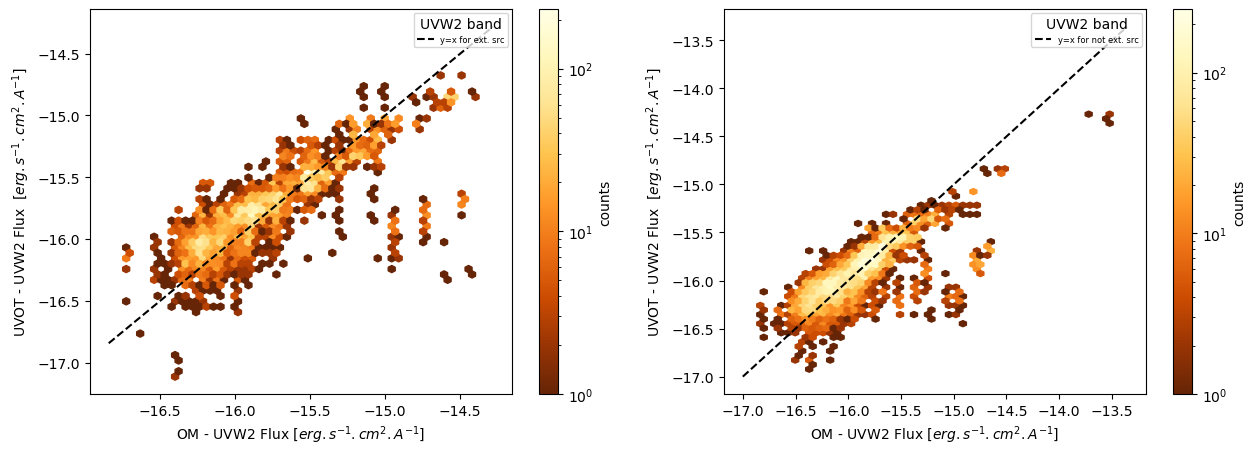

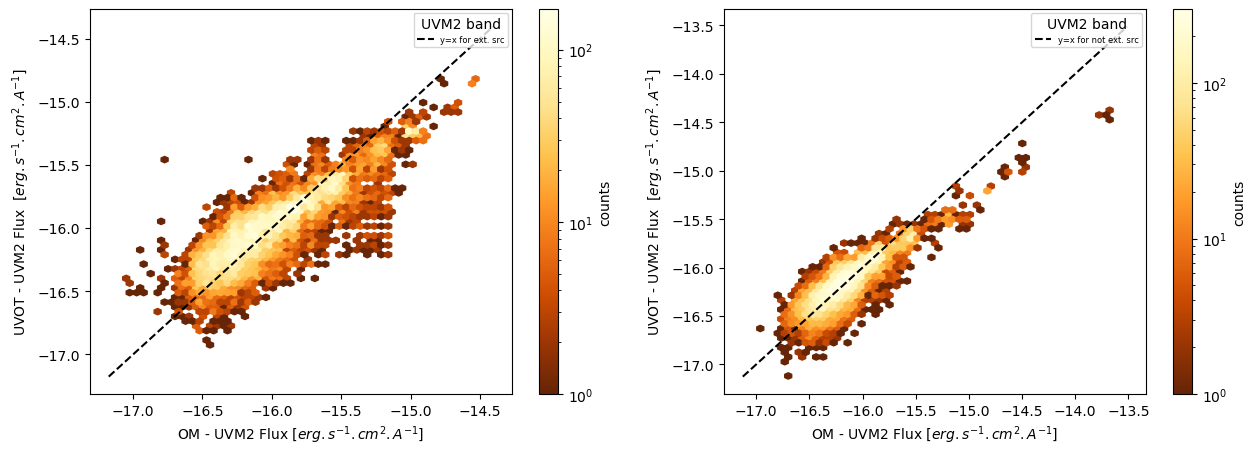

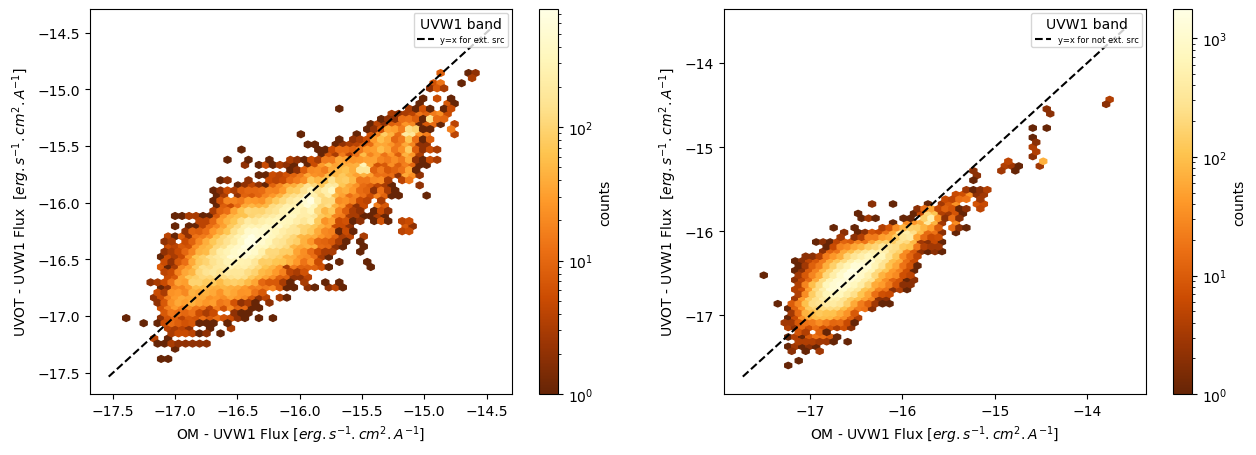

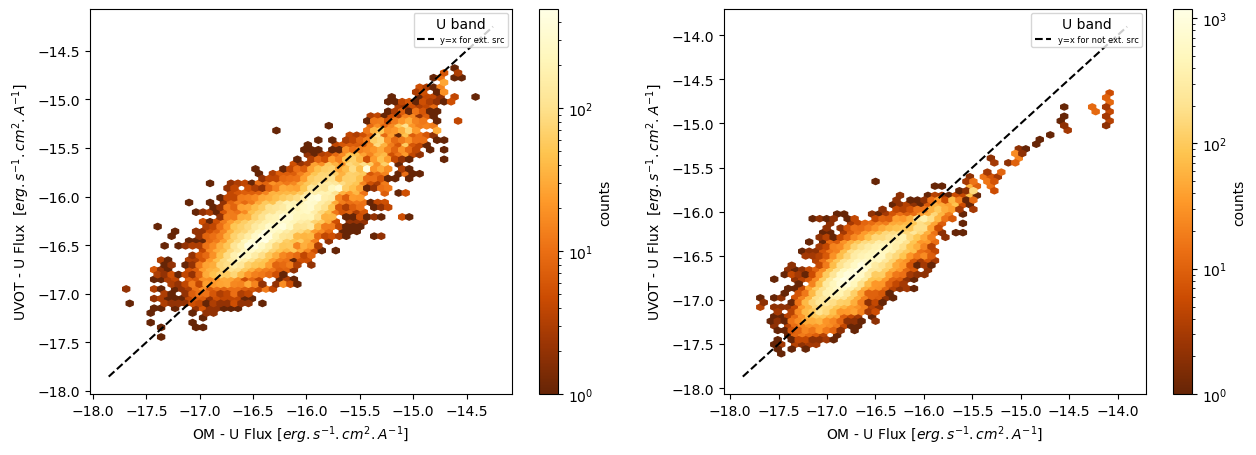

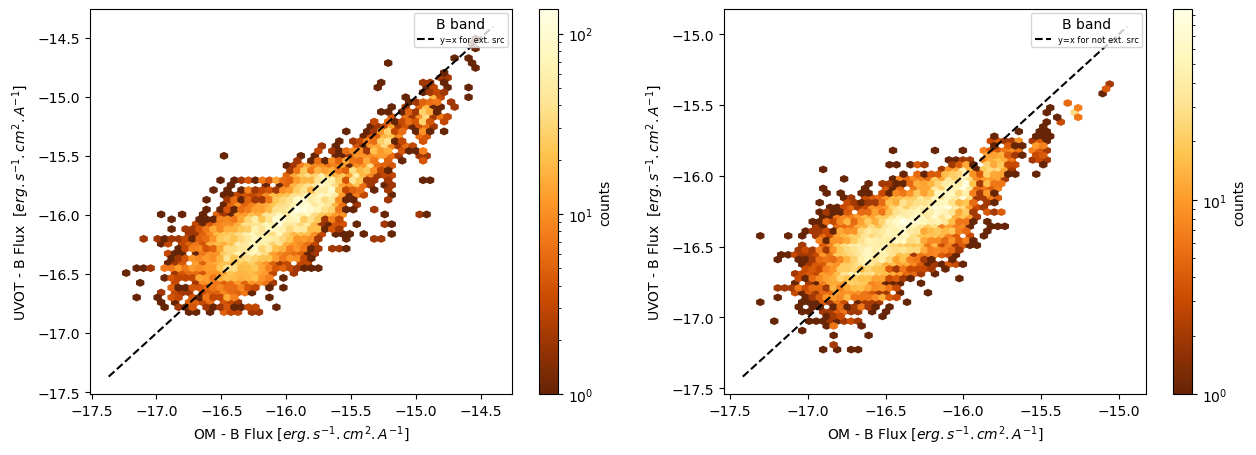

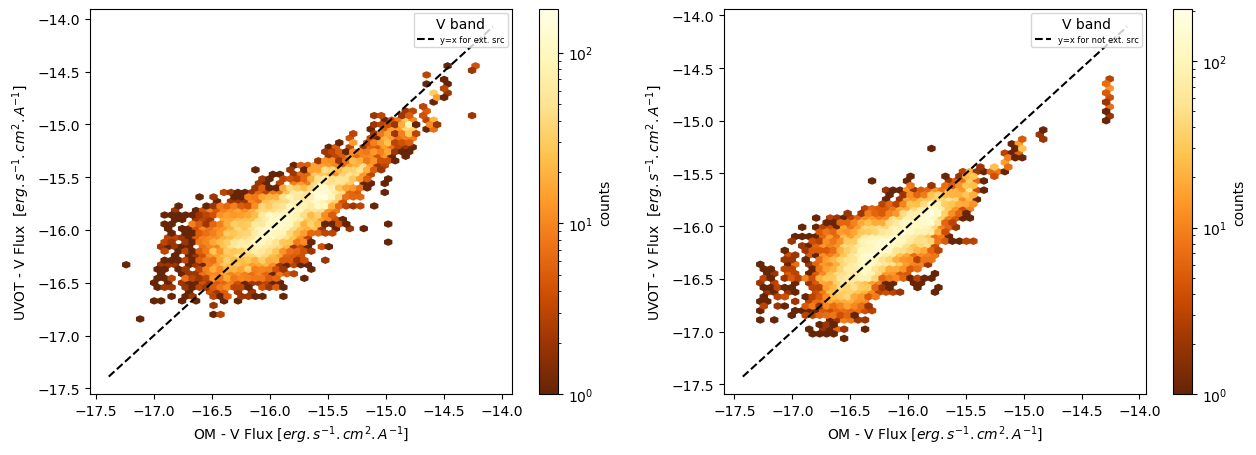

In [41]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT_cor[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index() 
    df_flux_uvot = df_flux_uvot[df_flux_uvot[flux_quality] == 0]

    # Data frame OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]

    # Merge results
    df_match = df_match.rename(columns={'SRCNUM_UVOT':'SRCNUM_UVOT_1','SRCNUM_OM':'SRCNUM_OM_1'})
    df_merge = df_match.merge(df_flux_uvot, left_on='SRCNUM_UVOT_1', right_on='SRCNUM', 
                              suffixes=(None,'_UVOT')).merge(df_flux_om, left_on='SRCNUM_OM_1', 
                                                             right_on='SRCNUM',suffixes=('_UVOT','_OM'))
   # Definition conservative of extended source
    ind_extended = (df_merge[flag_extended+ '_UVOT'] == "True") | (df_merge[flag_extended+ '_OM'] == "True")

    # Plot figure
    fig, (ax1, ax2) =plt.subplots(1,2,figsize=(15, 5))
     
    x=np.log10(df_merge.loc[ind_extended,flux_name + '_OM'])
    y=np.log10(df_merge.loc[ind_extended,flux_name + '_UVOT'])
    hb =ax1.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr_r')
    cb = fig.colorbar(hb, ax=ax1, label='counts')
    
    xmin, xmax= ax1.get_xlim()
    ax1.plot([xmin, xmax],[xmin, xmax], color='black', linestyle='dashed', label="y=x for ext. src")
    ax1.set_xlabel("OM - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax1.set_ylabel("UVOT - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax1.legend(loc='upper right',prop={'size': 6},title= flux + " band")

    x=np.log10(df_merge.loc[~ind_extended,flux_name + '_OM'])
    y=np.log10(df_merge.loc[~ind_extended,flux_name + '_UVOT']) 
    hb =ax2.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr_r')
    cb = fig.colorbar(hb, ax=ax2, label='counts')

    xmin, xmax= ax2.get_xlim()
    ax2.plot([xmin, xmax],[xmin, xmax], color='black', linestyle='dashed', label="y=x for not ext. src")
    ax2.set_xlabel("OM - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax2.set_ylabel("UVOT - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax2.legend(loc='upper right',prop={'size': 6},title= flux + " band")
    fig.savefig(roots_tfm + '/Calibration/OM_vs_UVOT_ ' + flux + '_galaxies_post_calib.png',dpi=1200) 

In [53]:
df_match = Table.read( roots_tfm + '/Swift-UVOT/Match_OM/match_uvot_om').to_pandas()
for flux in ['UVW2']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality,'OBSID','MJD']].dropna(subset=[flux_name]).reset_index() 
    df_flux_uvot = df_flux_uvot[df_flux_uvot[flux_quality] == 0]

    # Data frame OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality,'OBSID','MJD']].dropna(subset=[flux_name]).reset_index()  
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]

    # Merge results
    df_match = df_match.rename(columns={'SRCNUM_UVOT':'SRCNUM_UVOT_1','SRCNUM_OM':'SRCNUM_OM_1'})
    df_merge = df_match.merge(df_flux_uvot, left_on='SRCNUM_UVOT_1', right_on='SRCNUM', 
                              suffixes=(None,'_UVOT')).merge(df_flux_om, left_on='SRCNUM_OM_1', 
                                                             right_on='SRCNUM',suffixes=('_UVOT','_OM'))

    df_results_ra_dec=pd.DataFrame()
    df_results_entries=pd.DataFrame()
    df_results_entries = df_merge.loc[(np.log10(df_merge[flux_name + '_UVOT']) < -15.5) & (np.log10(df_merge[flux_name + '_UVOT']) > -16.5) &
    (np.log10(df_merge[flux_name + '_OM']) < -14.3) & (np.log10(df_merge[flux_name + '_OM']) > -15.2),:]
    df_results_ra_dec['SRCNUM_UVOT'] = df_results_entries['SRCNUM_UVOT'].unique()
    df_results_ra_dec = df_results_ra_dec.merge(df_match, left_on='SRCNUM_UVOT',right_on='SRCNUM_UVOT_1')
    df_results = df_results_ra_dec.merge(df_results_entries,on='SRCNUM_UVOT')

In [50]:
df_results_entries['OBSID_OM'].unique()

array([90393004, 90393002, 90393017, 90393012, 90393025, 90393021,
       90393014, 90393009, 90393020, 90393006, 90393043, 90393022,
       90393013, 90393007, 90393016, 90393010, 90393023, 90393003,
       90393001, 90393018, 90393005, 90393011, 90393046, 90393008,
       90393019, 90393026, 90393031, 90393027, 90393036, 90393044,
       90393029, 90393037, 90393038, 90393041, 90393040, 90393035,
       90393045, 90393032, 90393030, 90393042, 90393039, 90393034,
       90393015, 90393028, 90393033, 30083009, 30083014, 30083025,
       35895002, 30083040], dtype=int32)

In [54]:
df_results_entries.head()

,SRCNUM_OM_1,RA_OM,DEC_OM,POSERR_OM,COUNT_OM,SRCNUM_UVOT_1,RA_UVOT,DEC_UVOT,POSERR_UVOT,COUNT_UVOT,...,OBSID_UVOT,MJD_UVOT,index_OM,SRCNUM_OM,UVW2_FLUX_OM,UVW2_FLUX_ERR_OM,UVW2_EXTENDED_OM,UVW2_QUALITY_FLAG_OM,OBSID_OM,MJD_OM
7114,2330575,106.957565,-49.601221,0.499587,8,1426260,106.957815,-49.6012,0.456131,25,...,90393004,55301,45506,2330575,3.234178e-15,1.517007e-16,True,0,506200201,54236
7115,2330575,106.957565,-49.601221,0.499587,8,1426260,106.957815,-49.6012,0.456131,25,...,90393002,55293,45506,2330575,3.234178e-15,1.517007e-16,True,0,506200201,54236
7116,2330575,106.957565,-49.601221,0.499587,8,1426260,106.957815,-49.6012,0.456131,25,...,90393017,55353,45506,2330575,3.234178e-15,1.517007e-16,True,0,506200201,54236
7117,2330575,106.957565,-49.601221,0.499587,8,1426260,106.957815,-49.6012,0.456131,25,...,90393012,55333,45506,2330575,3.234178e-15,1.517007e-16,True,0,506200201,54236
7118,2330575,106.957565,-49.601221,0.499587,8,1426260,106.957815,-49.6012,0.456131,25,...,90393025,55385,45506,2330575,3.234178e-15,1.517007e-16,True,0,506200201,54236


In [52]:
df_results_entries.to_csv(roots_tfm + '/Calibration/UVW2_outliers.csv',index=True)
df_results_entries.shape[0]
df_results_entries['SRCNUM_OM'].unique()

array([2330575, 2331824, 2331865, 2332235, 2332507, 2334500, 2334519,
       2335099, 2335625, 2335818, 2336961, 2339356, 3498336], dtype=int32)

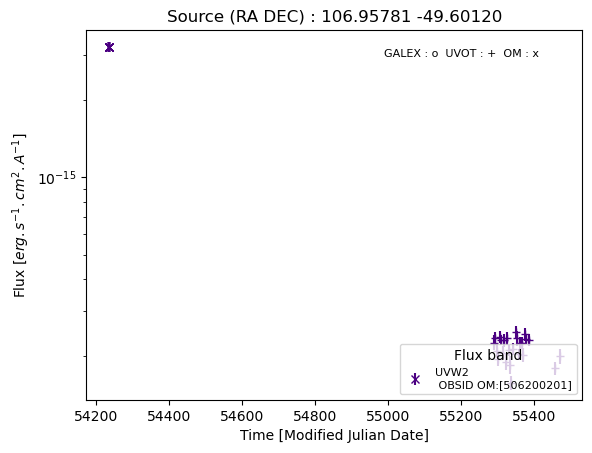

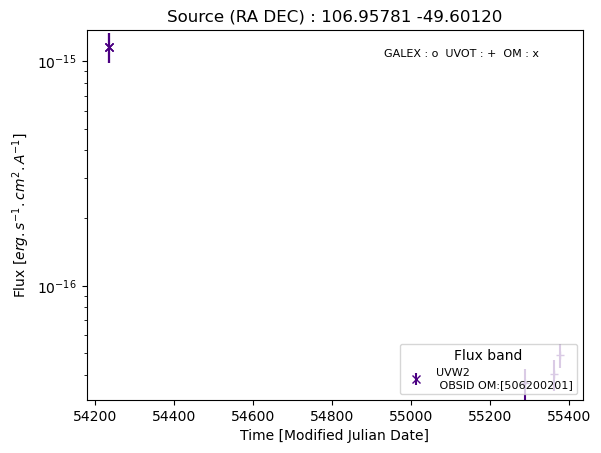

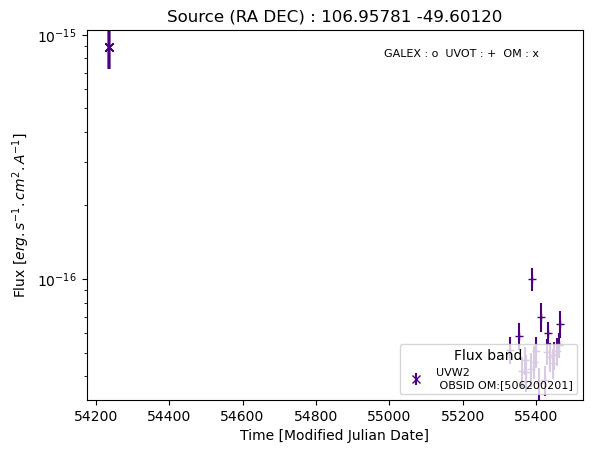

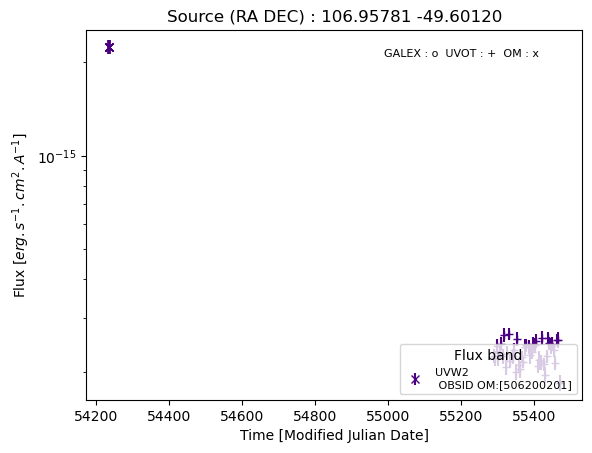

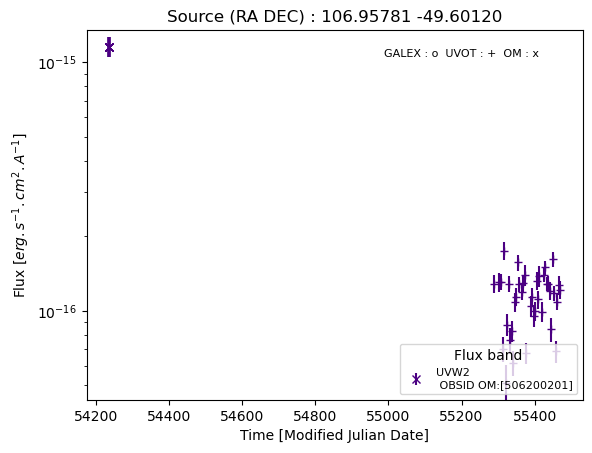

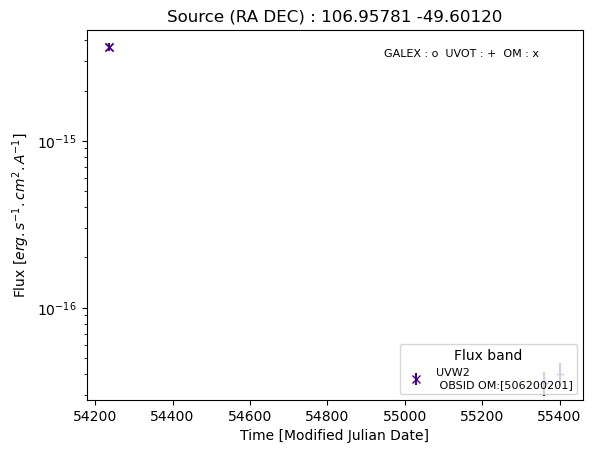

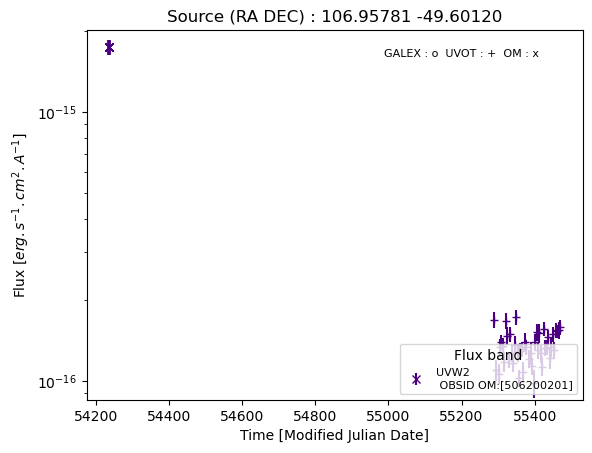

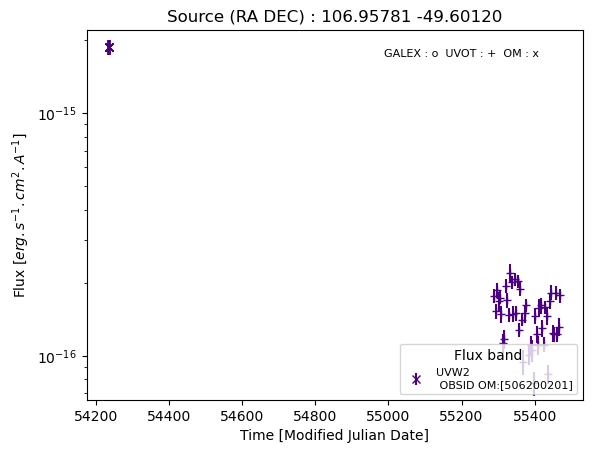

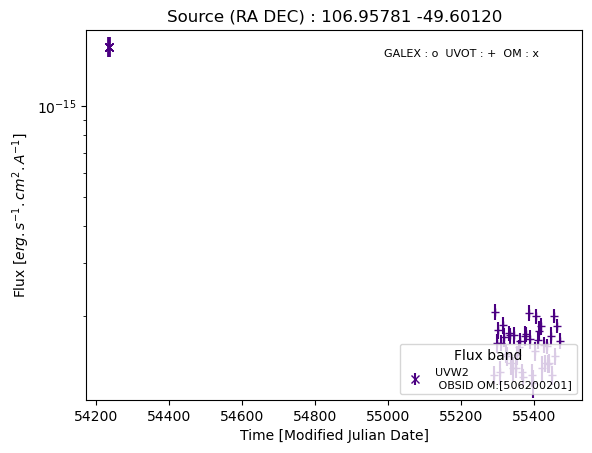

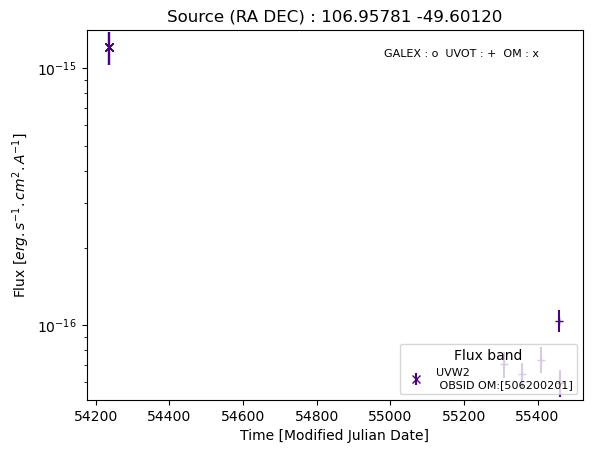

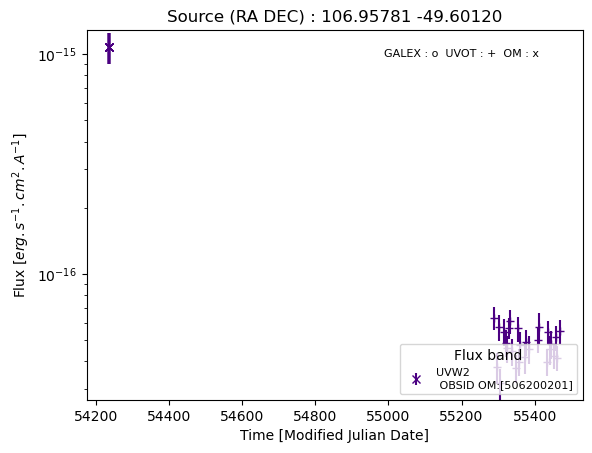

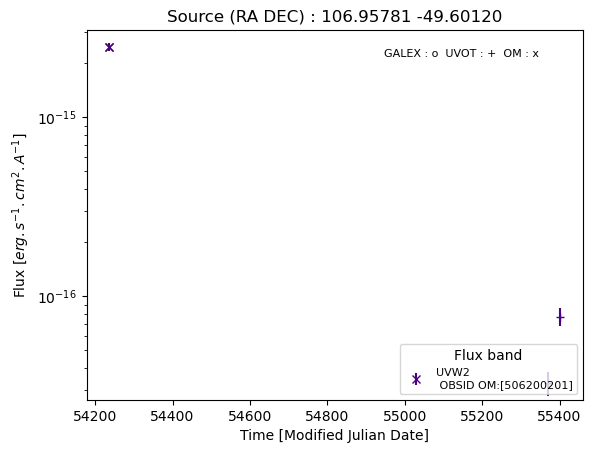

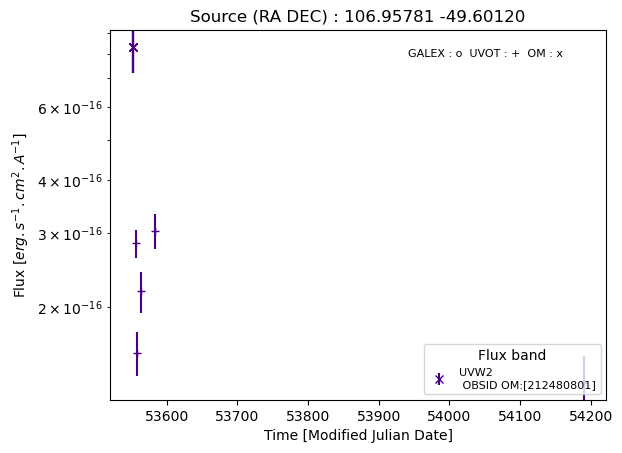

In [76]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fmt_dict = {'GALEX' : 'o', 'UVOT': '+', 'OM': 'x'}
color_dict = {'UVW2': 'indigo','UVW1': 'darkviolet','UVM2':'deeppink','U':'crimson','V':'limegreen','B':'royalblue'}
for srcnum in df_results_entries['SRCNUM_UVOT'].unique():
    fig, ax =plt.subplots()
    ax.set_yscale('log')
    ind_select = (df_results_entries['SRCNUM_UVOT']==srcnum)
    for flux in ['UVW2']:
        flux_key = flux + "_FLUX"
        flux_err_key = flux_key + "_ERR"
        ax.errorbar(df_results_entries.loc[ind_select,'MJD_UVOT'],df_results_entries.loc[ind_select,flux_key+'_UVOT'],
                    yerr=df_results_entries.loc[ind_select,flux_err_key+'_UVOT'], \
                    fmt=fmt_dict['UVOT'], color=color_dict[flux], \
                    ecolor=color_dict[flux])
        ax.errorbar(df_results_entries.loc[ind_select,'MJD_OM'],df_results_entries.loc[ind_select,flux_key+'_OM'],
            yerr=df_results_entries.loc[ind_select,flux_err_key+'_OM'], \
            fmt=fmt_dict['OM'], label = flux + '\n OBSID OM:'+ str(df_results_entries.loc[ind_select,'OBSID_OM'].unique()),
                    color=color_dict[flux], \
            ecolor=color_dict[flux])
    #ax.axvline(x=df_tde.loc[tde,'MJD'],color='orange',label='TDE detection date')
    ax.set_xlabel('Time [Modified Julian Date]')
    ax.set_ylabel("Flux [" + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.legend(loc='lower right',prop={'size': 8},title= "Flux band")
    ax.text(0.6, 0.95, 'GALEX : ' + fmt_dict['GALEX'] + '  UVOT : ' + fmt_dict['UVOT'] + '  OM : ' + fmt_dict['OM'],\
    transform=ax.transAxes, fontsize=8, verticalalignment='top')
    plt.title("Source (RA DEC) : " + "{0:.5f}".format(df_results_entries.loc[ind_select.index[0],'RA_UVOT']) + " " + \
              "{0:.5f}".format(df_results_entries.loc[ind_select.index[0],'DEC_UVOT']))
    fig.savefig(roots_tfm + '/Calibration/'+ 'SCRNUM_OM_'+str(srcnum)+'_flux.png',dpi=1200)

In [ ]:
db_path ='sqlite:///'+ roots_tfm + '/UVCatalogue.db'
dat_UVOT_cor.to_sql("Entries_UVOT", db_path, if_exists='replace', index=False, chunksize=1000, method="multi")
dat_OM.to_sql("Entries_OM", db_path, if_exists='replace', index=False, chunksize=1000, method="multi")

In [77]:
dat_OM.to_csv(roots_tfm + '/XMM-Newton/Entries_OM_galaxies.csv',index=False)
dat_UVOT_cor.to_csv(roots_tfm + '/Swift-UVOT/Entries_UVOT_galaxies.csv',index=False)

In [ ]:
#dat_UVOT.to_parquet(roots_tfm + '/'+project+'/'+'Entries_UVOT_parquet')